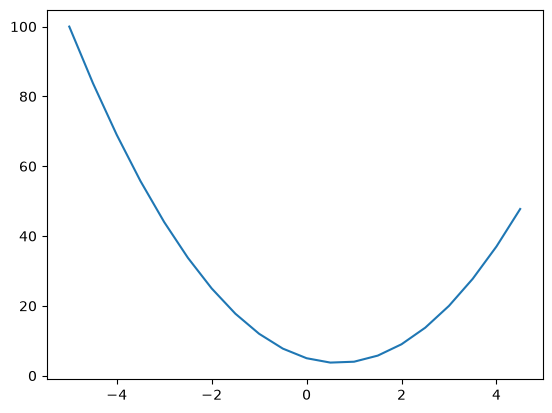

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
def f(x):
    return 3*x**2 -4*x + 5
f(9.0)
xs = np.arange(-5, 5, 0.5)
ys = f(xs)
plt.plot(xs,ys)



In [16]:
h = 0.00001
x = 2/3
(f(x+h) - f(x))/h

3.0000002482211127e-05

In [17]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [20]:
h = 0.0001
#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c+= h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [51]:
class Value:
    def __init__(self, data, _children=(), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
    def __repr__(self):
        return f"Value(data = {self.data})"
    def __mul__(self, other):
        out =  Value(self.data * other.data, (self, other), '*')
        return out
    def __add__(self, other):
            out =  Value(self.data + other.data, (self, other), '+')
            return out
a = Value(2.0, label = 'a')
b = Value(5.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
a * b
a + b
d = a*b + c; d.label = 'd'
f = Value(2.0, label = '2.0')
L = d*f; L.label = 'L'


In [43]:
d._prev
d._op

'+'

In [54]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr= {'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape= 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot
draw_dot(L)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH